In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt

In [ ]:
# upload kaggle.json

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle

In [ ]:
!kaggle datasets download -d iarunava/cell-images-for-detecting-malaria

Dataset URL: https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria
License(s): unknown
 98% 661M/675M [00:06<00:00, 176MB/s]
100% 675M/675M [00:07<00:00, 101MB/s]


In [ ]:
import os
import zipfile
import random
import shutil
from tqdm import tqdm

# STEP 1: Extracting ZIP directly into /content
zip_path = '/content/cell-images-for-detecting-malaria.zip'
extract_path = '/content/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


# STEP 2: Define paths to original class folders
parasitized_dir = os.path.join('/content/cell_images', 'Parasitized')
uninfected_dir = os.path.join('/content/cell_images', 'Uninfected')

# STEP 3: Create new split directory structure
base_dir = '/content/malaria_split'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

for category in ['Parasitized', 'Uninfected']:
    os.makedirs(os.path.join(train_dir, category), exist_ok=True)
    os.makedirs(os.path.join(test_dir, category), exist_ok=True)

# STEP 4: Split and copy
def split_and_copy_images(source_dir, train_dest, test_dest, split_ratio=0.8):
    images = os.listdir(source_dir)
    random.shuffle(images)

    split_index = int(len(images) * split_ratio)
    train_images = images[:split_index]
    test_images = images[split_index:]

    for img in tqdm(train_images, desc=f"Copying to {train_dest}"):
        shutil.copy(os.path.join(source_dir, img), os.path.join(train_dest, img))

    for img in tqdm(test_images, desc=f"Copying to {test_dest}"):
        shutil.copy(os.path.join(source_dir, img), os.path.join(test_dest, img))

# STEP 5: Apply to both classes
split_and_copy_images(parasitized_dir,
                      os.path.join(train_dir, 'Parasitized'),
                      os.path.join(test_dir, 'Parasitized'))

split_and_copy_images(uninfected_dir,
                      os.path.join(train_dir, 'Uninfected'),
                      os.path.join(test_dir, 'Uninfected'))

Copying to /content/malaria_split/train/Parasitized: 100%|██████████| 11024/11024 [00:01<00:00, 9525.43it/s] 
Copying to /content/malaria_split/test/Parasitized: 100%|██████████| 2756/2756 [00:00<00:00, 8877.15it/s]
Copying to /content/malaria_split/train/Uninfected: 100%|██████████| 11024/11024 [00:01<00:00, 8721.30it/s]
Copying to /content/malaria_split/test/Uninfected: 100%|██████████| 2756/2756 [00:00<00:00, 9565.91it/s]


In [ ]:
parasitized_count_train= len(os.listdir(os.path.join("/content/malaria_split/train", 'Parasitized')))
uninfected_count_train = len(os.listdir(os.path.join("/content/malaria_split/train", 'Uninfected')))
parasitized_count_test= len(os.listdir(os.path.join("/content/malaria_split/test", 'Parasitized')))
uninfected_count_test = len(os.listdir(os.path.join("/content/malaria_split/test", 'Uninfected')))

In [ ]:
print("Parasitized images in train:", parasitized_count_train)
print("Uninfected images in train:", uninfected_count_train)
print("Parasitized images in test:", parasitized_count_test)
print("Uninfected images in test:", uninfected_count_test)

Parasitized images in train: 11024
Uninfected images in train: 11024
Parasitized images in test: 2756
Uninfected images in test: 2756


In [ ]:
# Completely balance dataset

In [ ]:
# Generators(loading images in batches)
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/malaria_split/train',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256, 256)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/malaria_split/test',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256, 256)
)

Found 22046 files belonging to 2 classes.
Found 5512 files belonging to 2 classes.


In [ ]:
#  Normalizing pixel_value
def process(image, label):
  image = tf.cast(image/255. , tf.float32)
  return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

## Resnet50

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization


In [3]:
# Load the ResNet50 base model
base_model = tf.keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(256, 256, 3)
)

for layer in base_model.layers:
    if layer.name.startswith("conv5_"):
        layer.trainable = True
    else:
        layer.trainable = False

# Build the Sequential model
model = tf.keras.Sequential()

model.add(base_model)
model.add(tf.keras.layers.GlobalAveragePooling2D())
model.add(tf.keras.layers.Dense(256, activation='relu'))
model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dropout(0.1))
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))  # binary classification



94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 8, 8, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,145,281 (92.11 MB)

 Trainable params: 15,533,569 (59.26 MB)

 Non-trainable params: 8,611,712 (32.85 MB)

In [ ]:
# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=validation_ds
)

Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 115s 157ms/step - accuracy: 0.9233 - loss: 0.9122 - val_accuracy: 0.5102 - val_loss: 2.3310
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 104s 151ms/step - accuracy: 0.9346 - loss: 1.0692 - val_accuracy: 0.9508 - val_loss: 0.7276
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 141s 150ms/step - accuracy: 0.9422 - loss: 1.0499 - val_accuracy: 0.9285 - val_loss: 1.1284
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 105s 152ms/step - accuracy: 0.9391 - loss: 1.1267 - val_accuracy: 0.9389 - val_loss: 0.9718
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 105s 152ms/step - accuracy: 0.9398 - loss: 1.0355 - val_accuracy: 0.9505 - val_loss: 0.7167
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 104s 151ms/step - accuracy: 0.9433 - loss: 0.8286 - val_accuracy: 0.9162 - val_loss: 0.5490
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 106s 153ms/step - accuracy: 0.9438 - loss: 0.7303 - val_accuracy: 0.9334 - val_loss: 0.7812
Epoch 9/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 105s 153ms/step - accuracy: 0.9472 -

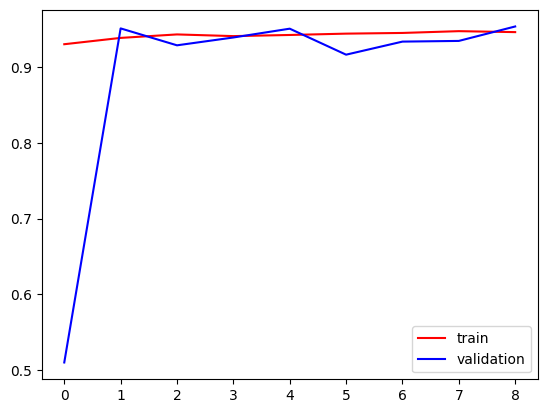

In [ ]:
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.legend()
plt.show()

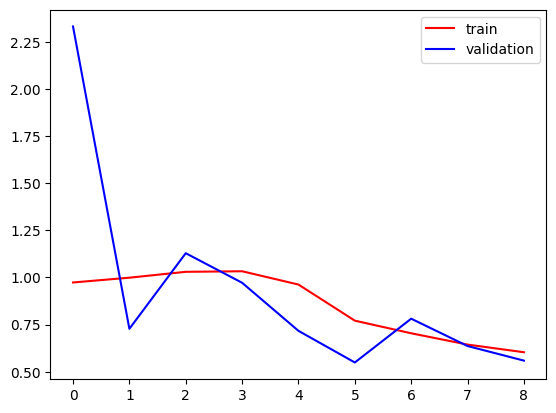

In [ ]:
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.legend()
plt.show()